# Problem 1: Clustering Algorithms

Unsupervised clustering algorithms are an efficient means to identify groups of related objects within large populations. Implement the following two clustering algorithms and apply them to the data in `cluster.txt`. The file contains data in the format `x`, `y`, `class`. If necessary, use a regular expression to remove lines that are empty or contain invalid data. You may safely ignore any line that fails the regular expression.



Part (a): K-Means Clustering

Use K-Means clustering with 3 clusters to label each `(x, y)` pair as `Head`, `Ear_Right`, or `Ear_Left`.

Produce a scatter plot marking each `(x, y)` pair as BLUE (`Head`), RED (`Ear_Left`), or GREEN (`Ear_Right`). Compare the K-Means predicted labels with the true labels and generate a confusion matrix showing the respective accuracies.

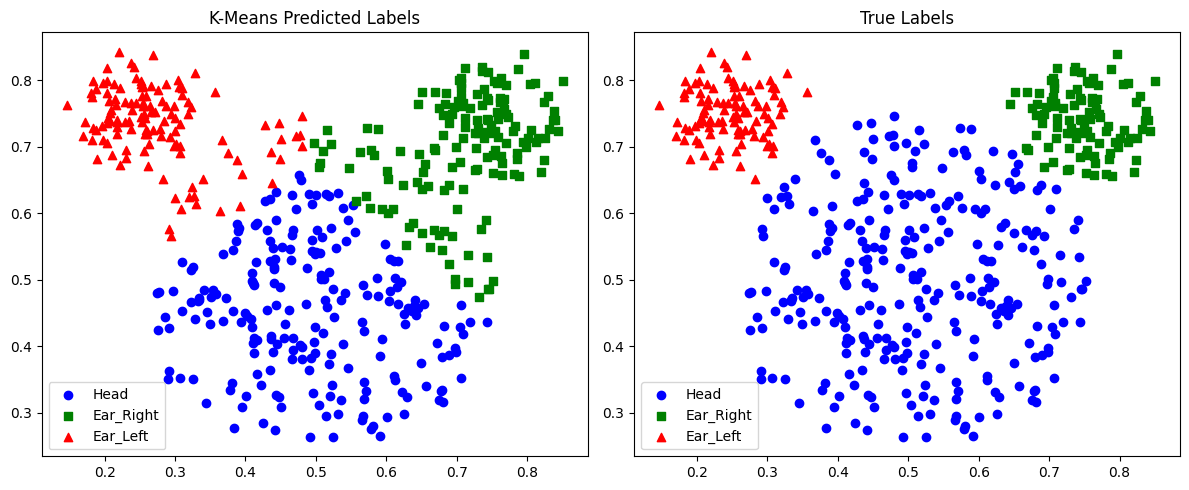

Confusion matrix:
[[211  54  25]
 [  0 100   0]
 [  0   0 100]]


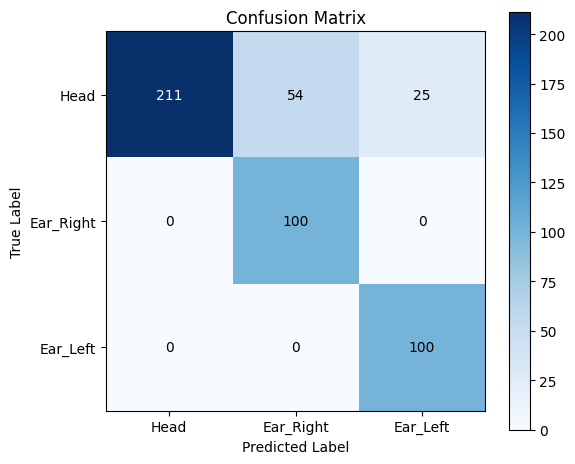

Overall accuracy: 0.8387755102040816
Overall accuracy: 83.88%


In [1]:
import numpy as np
import matplotlib.pyplot as plt


file = "cluster.txt"
X = []  # Data
y = []  # Labels

# Read the data from the file
with open(file, "r") as data:
    for line in data:
        line = line.strip()

        if line.startswith("#"):
            continue

        value = line.split()
        x1 = float(value[0])
        x2 = float(value[1])
        label = value[2]

        X.append([x1, x2])
        y.append(label)

X = np.array(X)
n, d = X.shape

proj = {"Head": 0, "Ear_right": 1, "Ear_left": 2}
y = np.array([proj[y[i]] for i in range(n)])
y_pred = np.zeros(n, dtype=int)

k = 3  # Number of clusters


indices = np.random.choice(n, k, replace=False)  # Randomly select initial cluster centers
centers = X[indices]

# Run K-Means until the cluster centers converge
while True:
    # Assign each sample to its nearest cluster center
    for i in range(n):
        dist = np.linalg.norm(X[i] - centers, axis=1)
        idx_nearest = np.argmin(dist)
        y_pred[i] = idx_nearest

    # Update each cluster center using the mean of its assigned samples
    new_centers = np.array([np.mean(X[y_pred == i], axis=0) for i in range(k)])

    # Stop when the cluster centers no longer change significantly
    if np.linalg.norm(new_centers - centers) < 1e-6:
        break

    centers = new_centers

# Determine the true class corresponding to each cluster
cluster_to_label = np.zeros(k, dtype=int)

for i in range(k):
    labels_in_cluster = y[y_pred == i]
    counts = np.bincount(labels_in_cluster, minlength=k)
    cluster_to_label[i] = np.argmax(counts)

y_pred = cluster_to_label[y_pred]

class_info = {
    0: ("Head", "blue", "o"),
    1: ("Ear_Right", "green", "s"),
    2: ("Ear_Left", "red", "^")
}

# Plot the results
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for class_id in range(k):
    name, color, marker = class_info[class_id]
    points = X[y_pred == class_id]

    axes[0].scatter(
        points[:, 0],
        points[:, 1],
        c=color,
        marker=marker,
        label=name
    )

axes[0].set_title("K-Means Predicted Labels")
axes[0].legend()

for class_id in range(k):
    name, color, marker = class_info[class_id]
    points = X[y == class_id]

    axes[1].scatter(
        points[:, 0],
        points[:, 1],
        c=color,
        marker=marker,
        label=name
    )

axes[1].set_title("True Labels")
axes[1].legend()

plt.tight_layout()
plt.show()

# Construct the confusion matrix
confusion = np.zeros((k, k), dtype=int)

for i in range(n):
    true_class = y[i]
    predicted_class = y_pred[i]
    confusion[true_class, predicted_class] += 1

print("Confusion matrix:")
print(confusion)

class_names = ["Head", "Ear_Right", "Ear_Left"]

# Visualize the confusion matrix
plt.figure(figsize=(6, 5))
plt.imshow(confusion, cmap="Blues")
plt.title("Confusion Matrix")
plt.colorbar()

plt.xticks(range(k), class_names)
plt.yticks(range(k), class_names)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

for i in range(k):
    for j in range(k):
        plt.text(
            j,
            i,
            confusion[i, j],
            ha="center",
            va="center",
            color="white"
            if confusion[i, j] > confusion.max() / 2
            else "black"
        )

plt.tight_layout()
plt.show()

# Calculate the overall classification accuracy
overall_accuracy = np.trace(confusion) / np.sum(confusion)

print("Overall accuracy:", overall_accuracy)
print(f"Overall accuracy: {overall_accuracy:.2%}")

Part (b): Gaussian Mixture Models with EM

Gaussian Mixture Models (GMMs) are a common method for clustering data from multimodal probability densities. Expectation Maximization (EM) is an iterative procedure used to compute locally optimal GMM parameters, including cluster means, covariance matrices, and mixing weights. The E-step updates the estimated membership probabilities, while the M-step uses these probabilities to update the mixture parameters.

1. Implement Expectation Maximization without using an EM implementation from NumPy, SciPy, or any other package. Use it to estimate the mixture parameters of a three-component GMM for the cluster dataset.

2. Initialize the membership probabilities for each sample using the K-Means labels from Part (a) as one-hot probabilities. Then compute the initial mean and covariance matrix for each mixture component.

3. Run EM until it has sufficiently converged. Use the log-likelihood as the convergence metric or monitor the class assignments until only small changes remain. Assign each data point to the mixture component with the highest membership probability.

4. Produce a Blue-Red-Green scatter plot as in Part (a), generate a confusion matrix showing the respective classification accuracies, and generate figures showing the class assignments during the first four iterations.

5. Comment on the differences between the clustering results in Parts (a) and (b). Describe any obvious differences between the plots and indicate which method performs better.

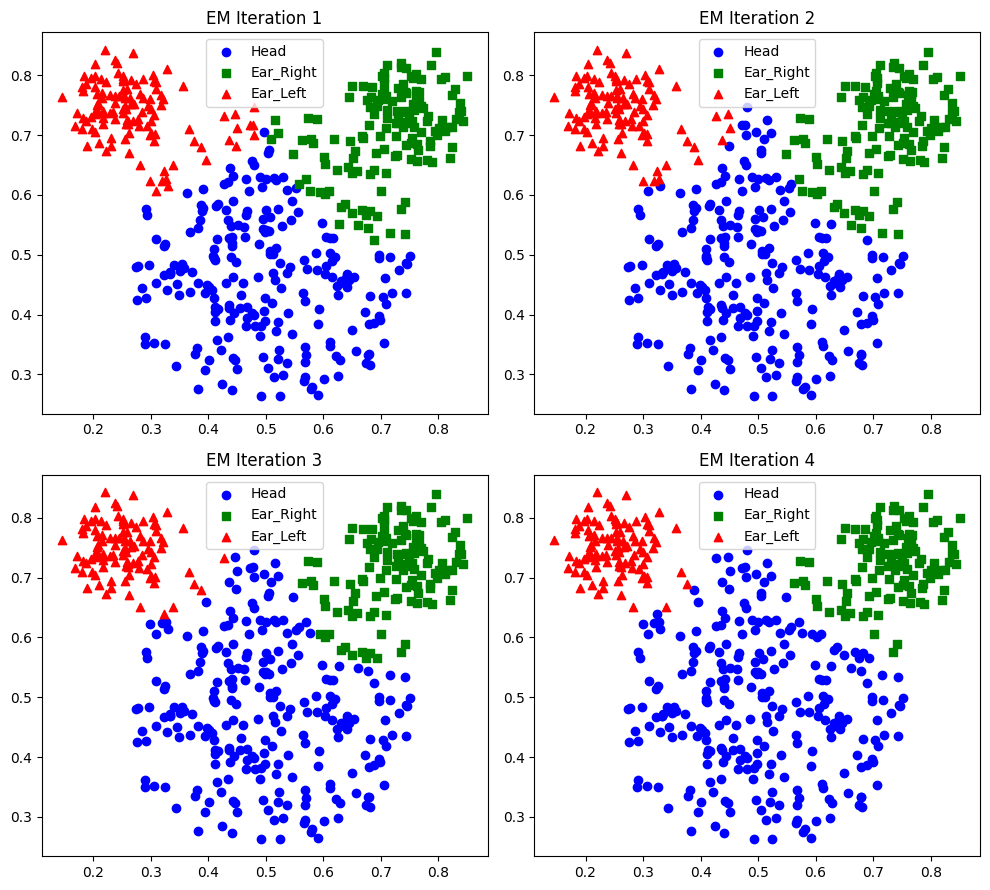

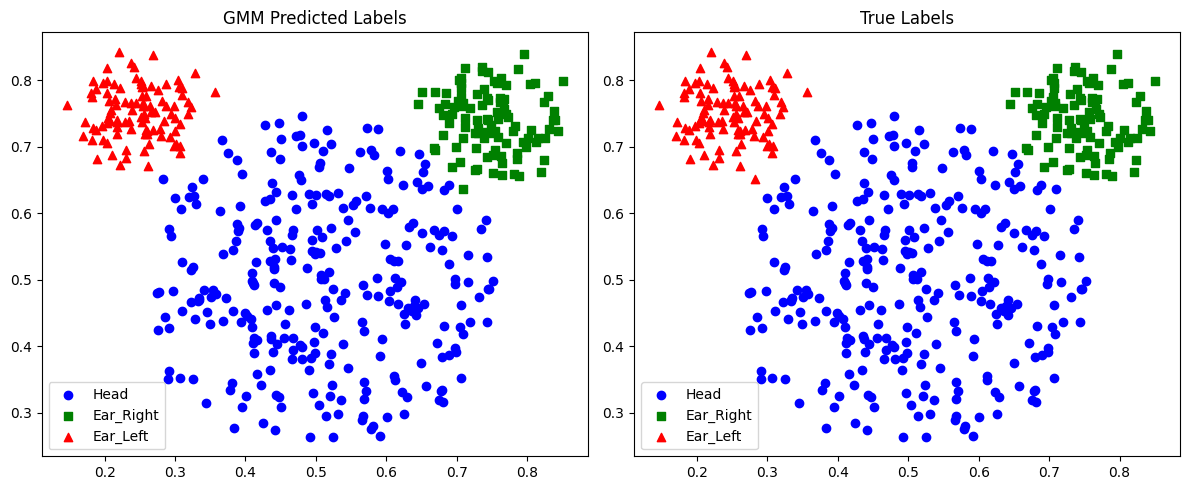

GMM Confusion Matrix:
[[289   1   0]
 [  0 100   0]
 [  1   0  99]]
GMM Overall Accuracy: 99.59%
Head Accuracy: 99.66%
Ear_Right Accuracy: 100.00%
Ear_Left Accuracy: 99.00%


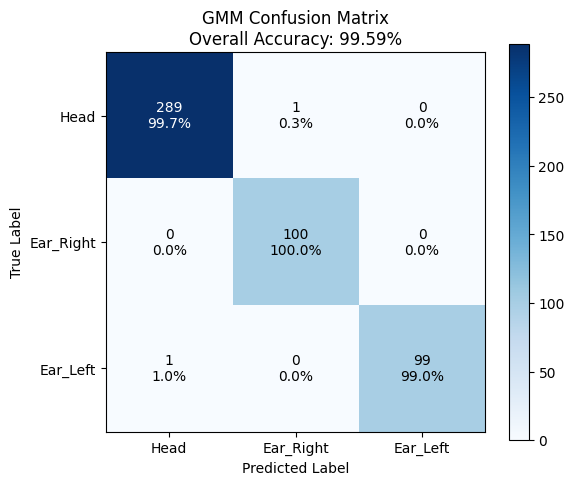

In [ ]:
gamma = np.eye(k)[y_pred]
n_k = np.sum(gamma, axis=0)
w = n_k / n
miu = (gamma.T @ X) / n_k.reshape(-1, 1)
covariance_matrix = np.zeros((k, d, d))  # Initialize one covariance matrix for each Gaussian component

for j in range(k):
    diff = X - miu[j]
    weighted_diff = gamma[:, j].reshape(-1, 1) * diff
    covariance_matrix[j] = (weighted_diff.T @ diff) / n_k[j]

likelihoods = []
first_four = []
iter = 0

while True:
    sample_likelihood = np.zeros(n)

    # E-step
    for i in range(n):
        weighted_pdf = np.zeros(k)

        for j in range(k):
            diff = X[i] - miu[j]
            inverse_cov = np.linalg.inv(covariance_matrix[j])
            determinant = np.linalg.det(covariance_matrix[j])
            exponent = -0.5 * diff.T @ inverse_cov @ diff
            denominator = np.sqrt((2 * np.pi) ** d * determinant)
            f_xi = np.exp(exponent) / denominator
            weighted_pdf[j] = w[j] * f_xi

        sample_likelihood[i] = np.sum(weighted_pdf)

        # Update the membership probabilities
        gamma[i] = (weighted_pdf /(sample_likelihood[i]))

    # Store the predicted components from the first four iterations
    current_pred = np.argmax(gamma, axis=1)

    if iter < 4:
        first_four.append(current_pred.copy())

    # Calculate the log-likelihood for the current iteration
    log_likelihood = np.sum(np.log(sample_likelihood))

    likelihoods.append(log_likelihood)

    # M-step
    for j in range(k):
        N_j = np.sum(gamma[:, j])
        miu[j] = (
            np.sum(gamma[:, j].reshape(-1, 1) * X,axis=0)/ N_j)
        diff = X - miu[j]
        covariance_matrix[j] = ((gamma[:, j].reshape(-1, 1) * diff).T@ diff/ N_j)
        # Add a small value to prevent the covariance matrix from becoming singular
        covariance_matrix[j] += 1e-6 * np.eye(d)

        w[j] = N_j / n

    # Check for convergence
    if iter > 0:
        change = abs(likelihoods[-1] - likelihoods[-2])

        if change < 1e-6:
            break

    iter += 1

# Assign each sample to the component with the highest probability
gmm_components = np.argmax(gamma, axis=1)

# Map GMM component IDs to true class IDs
component_to_label = np.zeros(k, dtype=int)

for component_id in range(k):
    labels_in_component = y[gmm_components == component_id]

    if len(labels_in_component) > 0:
        counts = np.bincount(labels_in_component, minlength=k)

        component_to_label[component_id] = np.argmax(counts)

    else:
        # This should rarely happen
        component_to_label[component_id] = component_id

# Convert component IDs to semantic class IDs
gmm_pred = component_to_label[gmm_components]


# Plot class assignments from the first four EM iterations
fig, axes = plt.subplots(2, 2, figsize=(10, 9))
axes = axes.flatten()

number_of_saved_iterations = min(4, len(first_four))

for iteration_number in range(number_of_saved_iterations):

    # Convert component IDs to semantic class IDs
    labels_iteration = component_to_label[
        first_four[iteration_number]
    ]

    for class_id in range(k):
        name, color, marker = class_info[class_id]

        points = X[labels_iteration == class_id]

        axes[iteration_number].scatter(
            points[:, 0],
            points[:, 1],
            color=color,
            marker=marker,
            label=name
        )

    axes[iteration_number].set_title(
        f"EM Iteration {iteration_number + 1}"
    )

    axes[iteration_number].legend()

# Hide unused plots if EM converges before four iterations
for plot_index in range(number_of_saved_iterations, 4):
    axes[plot_index].axis("off")

plt.tight_layout()
plt.show()

# Plot the final GMM predictions and true labels
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot the final GMM predictions
for class_id in range(k):
    name, color, marker = class_info[class_id]

    points = X[gmm_pred == class_id]

    axes[0].scatter(
        points[:, 0],
        points[:, 1],
        color=color,
        marker=marker,
        label=name
    )

axes[0].set_title("GMM Predicted Labels")
axes[0].legend()

# Plot the true labels
for class_id in range(k):
    name, color, marker = class_info[class_id]

    points = X[y == class_id]

    axes[1].scatter(
        points[:, 0],
        points[:, 1],
        color=color,
        marker=marker,
        label=name
    )

axes[1].set_title("True Labels")
axes[1].legend()

plt.tight_layout()
plt.show()

# Create the GMM confusion matrix
# Rows represent true labels and columns represent predicted labels
gmm_confusion = np.zeros((k, k), dtype=int)

for sample_id in range(n):
    true_class = y[sample_id]
    predicted_class = gmm_pred[sample_id]
    gmm_confusion[true_class, predicted_class] += 1

class_names = ["Head", "Ear_Right", "Ear_Left"]

# Calculate the overall accuracy
overall_accuracy = (np.trace(gmm_confusion)/ np.sum(gmm_confusion))

# Calculate the accuracy, or recall, of each class
class_accuracy = (np.diag(gmm_confusion)/ np.sum(gmm_confusion, axis=1))

print("GMM Confusion Matrix:")
print(gmm_confusion)

print(
    f"GMM Overall Accuracy: "
    f"{overall_accuracy:.2%}")

for class_id in range(k):
    print(
        f"{class_names[class_id]} Accuracy: "
        f"{class_accuracy[class_id]:.2%}"
)

# Display the confusion matrix as a heatmap
plt.figure(figsize=(6, 5))
plt.imshow(gmm_confusion,cmap="Blues")
plt.title("GMM Confusion Matrix\n"f"Overall Accuracy: {overall_accuracy:.2%}")
plt.colorbar()
plt.xticks(range(k), class_names)
plt.yticks(range(k), class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

row_totals = np.sum(
    gmm_confusion,
    axis=1,
    keepdims=True
)

confusion_percentages = (
    gmm_confusion
    / np.maximum(row_totals, 1)
)

for true_class in range(k):
    for predicted_class in range(k):

        cell_text = (
            f"{gmm_confusion[true_class, predicted_class]}"
            f"\n"
            f"{confusion_percentages[true_class, predicted_class]:.1%}"
        )

        plt.text(
            predicted_class,
            true_class,
            cell_text,
            ha="center",
            va="center",
            color=(
                "white"
                if gmm_confusion[true_class, predicted_class]
                > gmm_confusion.max() / 2
                else "black"
            )
        )

plt.tight_layout()
plt.show()

# The differences between the clustering results in Parts (a) and (b)

The clustering results show that the Gaussian Mixture Model performed substantially better than K-Means. K-Means achieved an overall accuracy of 83.88%, whereas the GMM achieved an overall accuracy of 99.59%, representing an improvement of approximately 15.71 percentage points.

The main difference is probably caused by the assumptions made by the two methods. K-Means assigns each point to the nearest cluster center using Euclidean distance, which produces relatively rigid linear boundaries and misclassifies more points near the overlapping regions. In contrast, the GMM models each cluster using a mean, covariance matrix, and mixing weight. This allows it to represent clusters with different shapes, orientations, and spreads. As a result, the GMM boundaries follow the actual distributions of the head and ears more accurately.